In [5]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
import numpy as np

### Task 1

**Problem 1. (Antidumping Filings and Chemical Imports)** Krupp and Pollard (1996) analyzed the effects of antidumping filings by U.S. chemical industries on imports of various chemicals. We focus here on one industrial chemical, barium chloride, a cleaning agent used in various chemical processes and in gasoline production. The data are contained in the file BARIUM. In the early 1980s, U.S. barium chloride producers believed that China was offering its U.S. imports an unfairly low price (an action known as dumping), and the barium chloride industry filed a complaint with the U.S. International Trade Commission (ITC) in October 1983. The ITC ruled in favor of the U.S. barium chloride industry in October 1984. There are several questions of interest in this case, but we will touch on only a few of them. First, were imports unusually high in the period immediately preceding the initial filing? Second, did imports change noticeably after an antidumping filing? Finally, what was the reduction in imports after a decision in favor of the U.S. industry?

To answer these questions, we follow Krupp and Pollard by defining three dummy variables: `befile6` is equal to 1 during the six months before filing, `affile6` indicates the six months after filing, and `afdec6` denotes the six months after the positive decision. The dependent variable is the volume of imports of barium chloride from China, `chnimp`, which we use in logarithmic form. We include as explanatory variables, all in logarithmic form, an index of chemical production, `chempi` (to control for overall demand for barium chloride), the volume of gasoline production, `gas` (another demand variable), and an exchange rate index, `rtwex`, which measures the strength of the dollar against several other currencies. The chemical production index was defined to be 100 in June 1977. The analysis here differs somewhat from Krupp and Pollard in that we use natural logarithms of all variables (except the dummy variables, of course), and we include all three dummy variables in the same regression. Estimate the model

$$\log(\text{chnimp}) = \beta_0 + \beta_1 \log(\text{chempi}) + \beta_2 \log(\text{gas}) + \beta_3 \log(\text{rtwex}) + \beta_4 \,\text{befile6} + \beta_5 \,\text{affile6} + \beta_6 \,\text{afdec6}$$

**(i)** Were Chinese imports statistically significantly higher during the six months prior to the filing of the complaint? What does the coefficient in `befile6` indicate?

**(ii)** How did the filing of the anti-dumping complaint (`affile6`) affect the volume of Chinese imports of barium chloride? Is this effect statistically significant?

**(iii)** What happened to Chinese imports after the ruling in favor of the U.S. industry (`afdec6`)?

**(iv)** How does total chemical production affect demand for Chinese imports? What sign is expected for the coefficient, and why?

**(v)** Does gasoline production have a statistically significant effect on Chinese imports?

**(vi)** Add a linear time trend to the above equation. Are any variables, other than the trend, statistically significant?

**(vii)** In the equation estimated in part (vi), test for joint significance of all variables except the time trend. What do you conclude?

**(viii)** Add monthly dummy variables to this equation and test for seasonality. Does including the monthly dummies change any other estimates or their standard errors in important ways?


In [7]:
barium = pd.read_csv("data/barium.csv")

In [8]:
y = barium["lchnimp"]
X = barium[["lchempi", "lgas", "lrtwex", "befile6", "affile6", "afdec6"]]
X = sm.add_constant(X)

ols_base = sm.OLS(y, X).fit()
print(ols_base.summary())

# (i) befile6: six months before filing vs. baseline (all dummies = 0)
beta_befile = ols_base.params["befile6"]
p_befile = ols_base.pvalues["befile6"]
print("\n--- Part (i): befile6 ---")
print(f"Coefficient: {beta_befile:.4f}")
print(f"p-value: {p_befile:.4f}")


                            OLS Regression Results                            
Dep. Variable:                lchnimp   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     9.064
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           3.25e-08
Time:                        10:27:55   Log-Likelihood:                -114.79
No. Observations:                 131   AIC:                             243.6
Df Residuals:                     124   BIC:                             263.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.8030     21.045     -0.846      0.3

In [10]:
# Task 1 (ii): effect of filing the complaint (affile6) — uses ols_base from previous cell

beta_affile = ols_base.params["affile6"]
p_affile = ols_base.pvalues["affile6"]
se_affile = ols_base.bse["affile6"]

print("--- Part (ii): affile6 (six months after filing vs. baseline) ---")
print(f"Coefficient: {beta_affile:.4f}")
print(f"Std. error:  {se_affile:.4f}")
print(f"p-value:     {p_affile:.4f}")


--- Part (ii): affile6 (six months after filing vs. baseline) ---
Coefficient: -0.0324
Std. error:  0.2643
p-value:     0.9026


In [12]:
# Task 1 (iii): imports after the ITC ruling in favor of U.S. industry (afdec6)

beta_afdec = ols_base.params["afdec6"]
p_afdec = ols_base.pvalues["afdec6"]
se_afdec = ols_base.bse["afdec6"]

print("--- Part (iii): afdec6 (six months after positive decision vs. baseline) ---")
print(f"Coefficient: {beta_afdec:.4f}")
print(f"Std. error:  {se_afdec:.4f}")
print(f"p-value:     {p_afdec:.4f}")


--- Part (iii): afdec6 (six months after positive decision vs. baseline) ---
Coefficient: -0.5652
Std. error:  0.2858
p-value:     0.0502


In [13]:
# Task 1 (iv): log(chempi) — chemical production and demand for Chinese imports

beta_chempi = ols_base.params["lchempi"]
p_chempi = ols_base.pvalues["lchempi"]
se_chempi = ols_base.bse["lchempi"]

print("--- Part (iv): lchempi (log chemical production index) ---")
print(f"Coefficient (elasticity w.r.t. chempi): {beta_chempi:.4f}")
print(f"Std. error:  {se_chempi:.4f}")
print(f"p-value:     {p_chempi:.4f}")
print(
    "Expected sign: + — stronger overall U.S. chemical production raises derived demand for inputs such as barium chloride, so imports should move with that activity (other things equal)."
)


--- Part (iv): lchempi (log chemical production index) ---
Coefficient (elasticity w.r.t. chempi): 3.1172
Std. error:  0.4792
p-value:     0.0000
Expected sign: + — stronger overall U.S. chemical production raises derived demand for inputs such as barium chloride, so imports should move with that activity (other things equal).


In [15]:
# Task 1 (v): log(gas) — is gasoline production statistically significant for imports?

beta_gas = ols_base.params["lgas"]
p_gas = ols_base.pvalues["lgas"]
se_gas = ols_base.bse["lgas"]

print("--- Part (v): lgas (log gasoline production) ---")
print(f"Coefficient (elasticity w.r.t. gas): {beta_gas:.4f}")
print(f"Std. error:  {se_gas:.4f}")
print(f"p-value:     {p_gas:.4f}")


--- Part (v): lgas (log gasoline production) ---
Coefficient (elasticity w.r.t. gas): 0.1964
Std. error:  0.9066
p-value:     0.8289


In [17]:
# Task 1 (vi): baseline model + linear time trend t (barium.csv column `t`)

y_vi = barium["lchnimp"]
X_vi = barium[["lchempi", "lgas", "lrtwex", "befile6", "affile6", "afdec6", "t"]]
X_vi = sm.add_constant(X_vi)

ols_trend = sm.OLS(y_vi, X_vi).fit()
print(ols_trend.summary())

alpha = 0.05
non_trend = [c for c in ols_trend.params.index if c != "t"]
print("\n--- Part (vi): significant at 5% among regressors other than t? ---")
for name in non_trend:
    p = ols_trend.pvalues[name]
    flag = "yes" if p < alpha else "no"
    print(f"  {name:10s}  p = {p:.4f}  -> {flag}")


                            OLS Regression Results                            
Dep. Variable:                lchnimp   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     9.951
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           8.36e-10
Time:                        10:42:51   Log-Likelihood:                -109.21
No. Observations:                 131   AIC:                             234.4
Df Residuals:                     123   BIC:                             257.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3675     20.782     -0.114      0.9

In [18]:
# Task 1 (vii): joint significance of all regressors except time trend t
# H0: lchempi, lgas, lrtwex, befile6, affile6, afdec6 are all zero (intercept not restricted)

f_joint = ols_trend.f_test(
    "lchempi = lgas = lrtwex = befile6 = affile6 = afdec6 = 0"
)
print("--- Part (vii): joint F-test — H0: all six coefficients (lchempi…afdec6) = 0; const and t free ---")
print(f_joint)

alpha = 0.05
p_f = float(np.asarray(f_joint.pvalue).ravel()[0])
if p_f < alpha:
    conclusion = "reject H0: the six regressors are jointly significant at 5%."
else:
    conclusion = "fail to reject H0: the six regressors are not jointly significant at 5%."
print("\nConclusion:", conclusion)


--- Part (vii): joint F-test — H0: all six coefficients (lchempi…afdec6) = 0; const and t free ---
<F test: F=0.5402498317758507, p=0.7767277194927064, df_denom=123, df_num=6>

Conclusion: fail to reject H0: the six regressors are not jointly significant at 5%.


### Task 2

**Problem 2.** Consider data in `sales.csv` (attached file).

**Description:** Units: Millions of Dollars, Not Seasonally Adjusted. Frequency: Monthly.

**Citation:** U.S. Census Bureau, Retail Sales: Gift, Novelty, and Souvenir Stores [MRTSSM45322USN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/MRTSSM45322USN, April 3, 2025. The data contain monthly retail sales of U.S. gift stores. The series exhibits a clear upward trend and strong seasonality (a sharp peak in December). The task is divided into two independent parts so that you can see when and why each approach is used.

**Part I. Classical Decomposition and Regression.** We explicitly model trend and seasonality as parts of a regression equation. Coefficients carry economic interpretation. The goal is to understand the structure of the series.

1. Plot the retail sales time series. Describe what you observe.
   - Is there an upward or downward trend?
   - Is there a regular seasonal wave?
   - Are there sharp anomalies (e.g. COVID-19)?  
   *Hint:* For gift stores a sharp December peak (Christmas) is expected. Does your plot confirm this?

2. Estimate three trend models: linear, quadratic, and exponential. For each, overlay the fitted trend on the original series.
   - Which trend shape fits the series best visually?
   - How would you interpret the coefficient on $t$ in the linear trend in terms of sales?  
   *Hint:* For the exponential trend, estimate $\log(\text{sales}) \sim t$. The coefficient on $t$ is then approximately the monthly growth rate in percent.

3. Subtract the estimated trend from the original series for each of the three models. Plot the residuals. Compare rolling means and rolling standard deviations across the three detrended series.
   - Does the rolling mean stay close to zero after detrending?
   - Has the rolling standard deviation become more stable?
   - Run an ADF test for each residual series. What do the results tell you about whether detrending worked?  
   *Hint:* Detrending “worked” if the residuals show no systematic drift and the stationarity test fails to reject stationarity.

4. Test for the presence of seasonality. Consider both monthly and quarterly patterns.
   - Is a seasonal pattern visible in the plot? In which months are sales systematically higher or lower?
   - How can you formally prove seasonality? (*Hint:* use an $F$-test for joint significance of monthly dummies.)

5. Explain why it can be useful to remove seasonality from the data. Include monthly dummy variables in the regression and interpret the results.
   - What does the coefficient on the December dummy mean relative to the base month?
   - Did the trend estimates change after adding monthly dummies?  
   *Hint:* Including both a trend and monthly dummies in one regression is standard practice in classical decomposition.

6. Compare all three trend models in terms of detrending quality. Which is best, and how do you know?


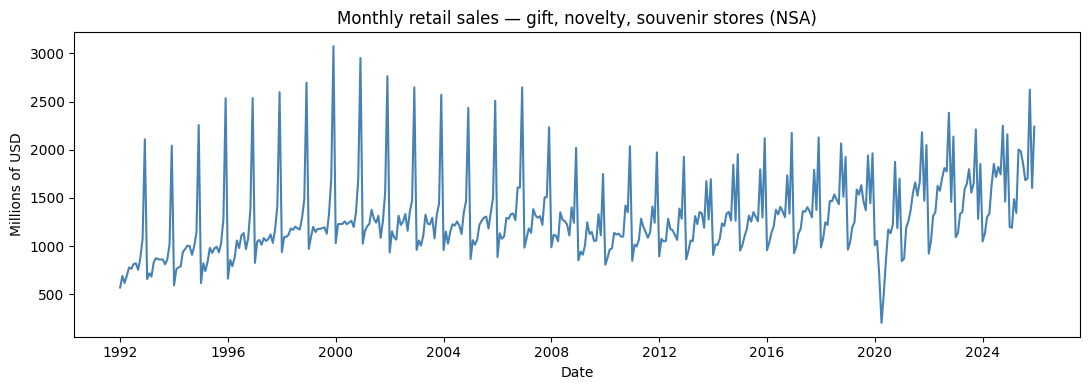

In [20]:
# Task 2.1 — load FRED retail sales (same series as cited; file MRTSSM45322USN.csv) and plot
from pathlib import Path

sales_path = Path("data/MRTSSM45322USN.csv")
sales_df = pd.read_csv(sales_path, parse_dates=["observation_date"])
sales_df = sales_df.rename(columns={"MRTSSM45322USN": "sales"})
sales_df["t"] = np.arange(len(sales_df), dtype=float)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sales_df["observation_date"], sales_df["sales"], color="steelblue")
ax.set_title("Monthly retail sales — gift, novelty, souvenir stores (NSA)")
ax.set_xlabel("Date")
ax.set_ylabel("Millions of USD")
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     24.16
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.23e-10
Time:                        12:12:39   Log-Likelihood:                -3019.2
No. Observations:                 408   AIC:                             6044.
Df Residuals:                     405   BIC:                             6056.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1068.2043     58.718     18.192      0.0

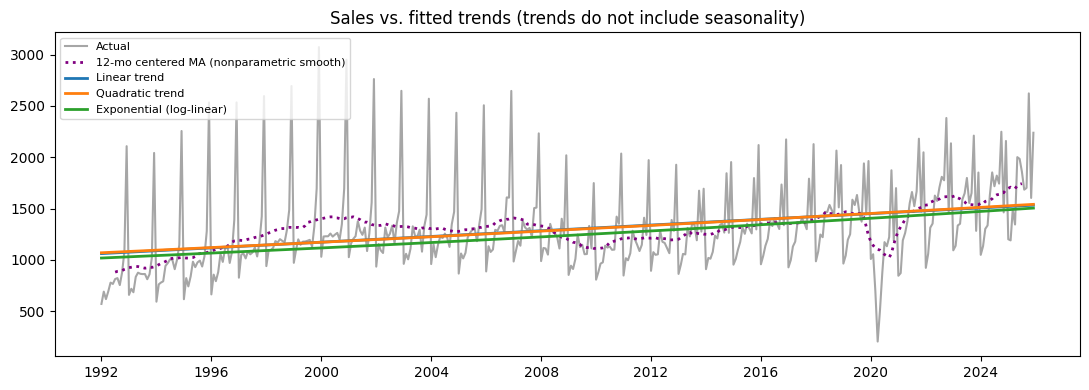

Linear: coef on t = 1.1604 -> avg. change in sales (USD mn) per month.
Log-linear: coef on t = 0.000962 -> approx. monthly growth ~ 0.096 %


In [29]:
# Task 2.2 — linear, quadratic, and exponential (log-linear) trends; overlay on sales

y = sales_df["sales"]
t = sales_df["t"]
t2 = t ** 2

ols_lin = sm.OLS(y, sm.add_constant(t)).fit()
# print(ols_lin.summary())
y_hat_lin = ols_lin.fittedvalues

ols_quad = sm.OLS(y, sm.add_constant(pd.concat([t, t2], axis=1))).fit()
y_hat_quad = ols_quad.fittedvalues
print(ols_quad.summary())

logy = np.log(y.astype(float))
ols_log = sm.OLS(logy, sm.add_constant(t)).fit()
y_hat_exp = np.exp(ols_log.fittedvalues)

# 12-month centered MA: smooths within-year seasonality so you can compare "slow" shape to parametric trends
ma12 = y.rolling(12, center=True, min_periods=12).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sales_df["observation_date"], y, label="Actual", color="black", alpha=0.35)
ax.plot(
    sales_df["observation_date"],
    ma12,
    label="12-mo centered MA (nonparametric smooth)",
    color="purple",
    lw=2,
    ls=":",
)
ax.plot(sales_df["observation_date"], y_hat_lin, label="Linear trend", lw=2)
ax.plot(sales_df["observation_date"], y_hat_quad, label="Quadratic trend", lw=2)
ax.plot(sales_df["observation_date"], y_hat_exp, label="Exponential (log-linear)", lw=2)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Sales vs. fitted trends (trends do not include seasonality)")
plt.tight_layout()
plt.show()

b1 = ols_lin.params["t"]
g_approx = 100 * (np.exp(ols_log.params["t"]) - 1)
print("Linear: coef on t =", round(b1, 4), "-> avg. change in sales (USD mn) per month.")
print("Log-linear: coef on t =", round(ols_log.params["t"], 6), "-> approx. monthly growth ~", round(g_approx, 3), "%")


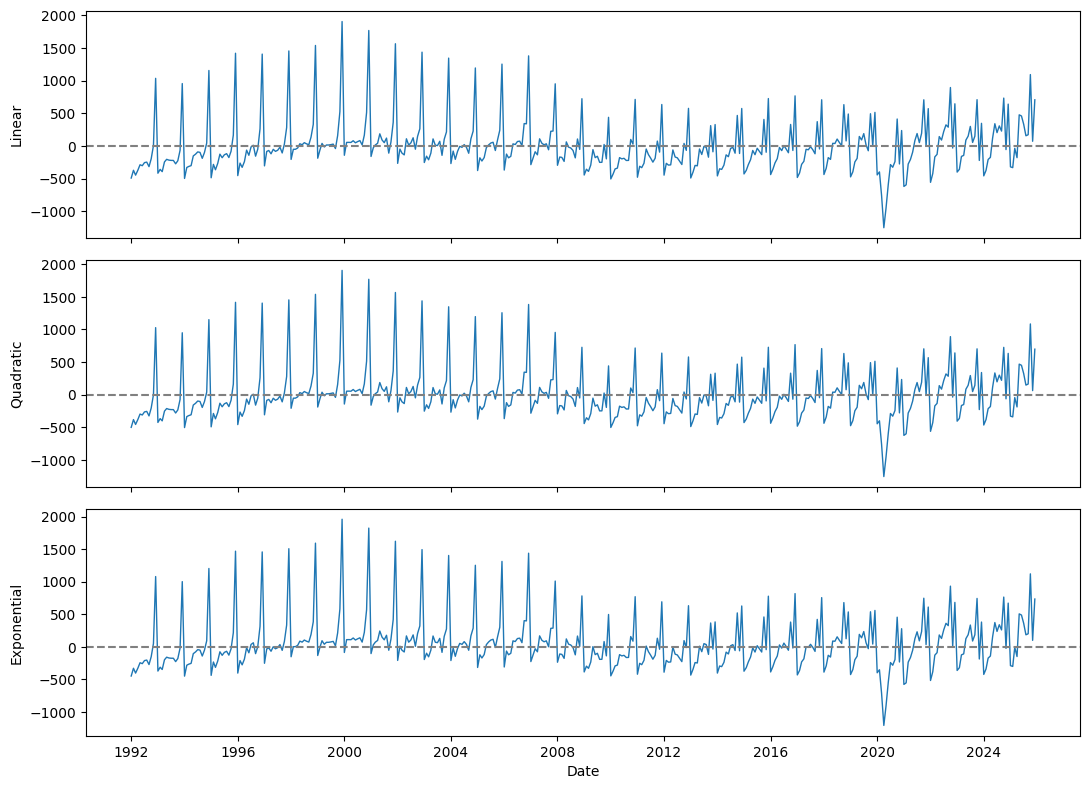

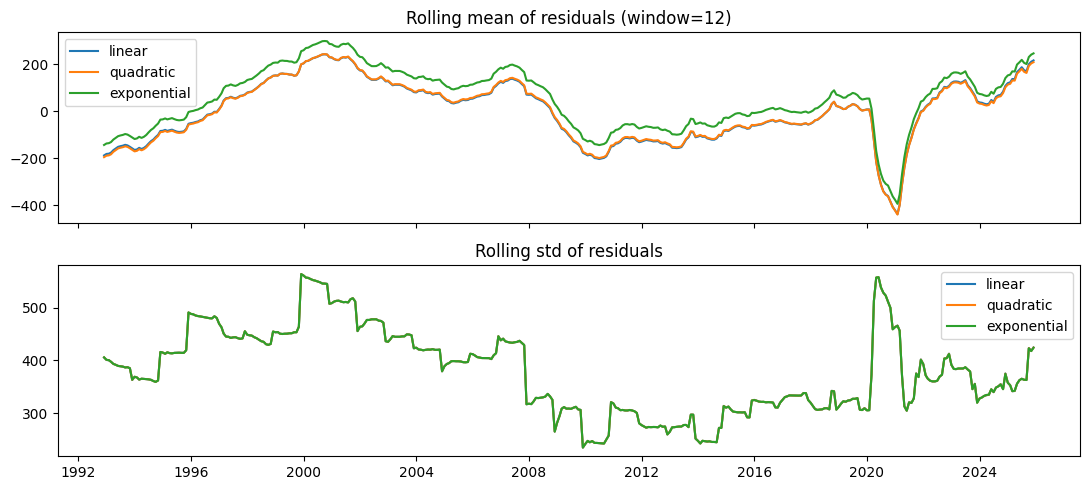

ADF on detrended residuals (H0: unit root; low p => reject H0 => more stationary):

  linear        ADF stat= -2.5558  p-value=0.1025
  quadratic     ADF stat= -2.5878  p-value=0.09555
  exponential   ADF stat= -2.6109  p-value=0.09076


In [24]:
# Task 2.3 — detrended residuals, rolling mean/std, ADF on each residual series
from statsmodels.tsa.stattools import adfuller

res_lin = y - y_hat_lin
res_quad = y - y_hat_quad
res_exp = y - y_hat_exp

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, s, title in zip(axes, [res_lin, res_quad, res_exp], ["Linear", "Quadratic", "Exponential"]):
    ax.plot(sales_df["observation_date"], s, lw=1)
    ax.axhline(0, color="gray", ls="--")
    ax.set_ylabel(title)
plt.xlabel("Date")
plt.tight_layout()
plt.show()

win = 12
roll = {
    "linear": (res_lin.rolling(win).mean(), res_lin.rolling(win).std()),
    "quadratic": (res_quad.rolling(win).mean(), res_quad.rolling(win).std()),
    "exponential": (res_exp.rolling(win).mean(), res_exp.rolling(win).std()),
}
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for name, (rm, rs) in roll.items():
    axes[0].plot(sales_df["observation_date"], rm, label=name)
    axes[1].plot(sales_df["observation_date"], rs, label=name)
axes[0].set_title(f"Rolling mean of residuals (window={win})")
axes[0].legend()
axes[1].set_title("Rolling std of residuals")
axes[1].legend()
plt.tight_layout()
plt.show()

print("ADF on detrended residuals (H0: unit root; low p => reject H0 => more stationary):\n")
for label, s in [("linear", res_lin), ("quadratic", res_quad), ("exponential", res_exp)]:
    stat, p, _, _, crit, _ = adfuller(s.values, autolag="AIC", regression="c")
    print(f"  {label:12s}  ADF stat={stat:8.4f}  p-value={p:.4g}")


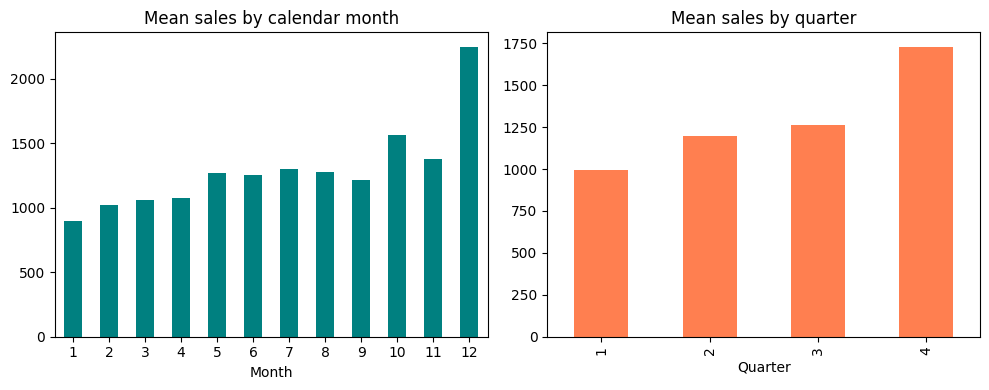

F-test: joint significance of Feb-Dec dummies (Jan = base), no time trend in this aux. regression
<F test: F=61.70964680309509, p=7.779574359756443e-79, df_denom=396, df_num=11>

With linear trend + monthly dummies (standard spec):
<F test: F=81.26313386537619, p=3.0715003485056987e-94, df_denom=395, df_num=11>


In [25]:
# Task 2.4 — seasonal patterns (month / quarter) and F-test on monthly dummies

sales_df["month"] = sales_df["observation_date"].dt.month
sales_df["quarter"] = sales_df["observation_date"].dt.quarter

month_means = sales_df.groupby("month")["sales"].mean()
quarter_means = sales_df.groupby("quarter")["sales"].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
month_means.plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Mean sales by calendar month")
axes[0].set_xlabel("Month")
axes[0].tick_params(axis="x", rotation=0)
quarter_means.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Mean sales by quarter")
axes[1].set_xlabel("Quarter")
plt.tight_layout()
plt.show()

month_dum = pd.get_dummies(sales_df["month"], prefix="m", drop_first=True)
X_season = sm.add_constant(month_dum.astype(float))
ols_m = sm.OLS(sales_df["sales"], X_season).fit()
restrict = ", ".join([f"{c} = 0" for c in month_dum.columns])
f_m = ols_m.f_test(restrict)
print("F-test: joint significance of Feb-Dec dummies (Jan = base), no time trend in this aux. regression")
print(f_m)
print("\nWith linear trend + monthly dummies (standard spec):")
X_ts = sm.add_constant(pd.concat([sales_df[["t"]], month_dum.astype(float)], axis=1))
ols_ts = sm.OLS(sales_df["sales"], X_ts).fit()
restrict2 = ", ".join([f"{c} = 0" for c in month_dum.columns])
print(ols_ts.f_test(restrict2))


In [27]:
# Task 2.6 — compare detrending quality across the three trend models

def detrend_metrics(resid, name):
    stat, pval, _, _, _, _ = adfuller(resid.values, autolag="AIC", regression="c")
    rm = resid.rolling(12).mean().dropna()
    rs = resid.rolling(12).std().dropna()
    return {
        "model": name,
        "rmse": float(np.sqrt(np.mean(resid ** 2))),
        "mean_abs_roll_mean": float(rm.abs().mean()),
        "mean_roll_std": float(rs.mean()),
        "adf_p": float(pval),
    }

rows = [
    detrend_metrics(res_lin, "linear"),
    detrend_metrics(res_quad, "quadratic"),
    detrend_metrics(res_exp, "exponential"),
]
comp = pd.DataFrame(rows).set_index("model")
print("Lower RMSE / lower |rolling mean| / ADF p-value closer to 0 (reject unit root) suggest better detrending.\n")
print(comp.to_string())
best_adf = comp["adf_p"].idxmin()
best_rmse = comp["rmse"].idxmin()
print(f"\nSmallest RMSE: {best_rmse}; strongest ADF (lowest p): {best_adf}.")
print("Use this table + plots in 2.3 to justify which model detrends best.")


Lower RMSE / lower |rolling mean| / ADF p-value closer to 0 (reject unit root) suggest better detrending.

                   rmse  mean_abs_roll_mean  mean_roll_std     adf_p
model                                                               
linear       395.838974          109.841186     379.467466  0.102480
quadratic    395.822280          109.688826     379.466346  0.095555
exponential  399.151387          115.641778     379.462603  0.090764

Smallest RMSE: quadratic; strongest ADF (lowest p): exponential.
Use this table + plots in 2.3 to justify which model detrends best.


### Task 3

**Part II. ARIMA: The Differencing Approach**

Here we do not estimate the trend explicitly and do not add seasonal dummies. Instead, the trend is removed by differencing the series. The goal is to build a model for forecasting.

1. Run ADF tests on the raw sales series. Use the specification with a constant and a linear trend.
   - What do the tests indicate? Is the series stationary?  
   *Hint:* If the plot shows an obvious upward trend, an ADF specification without a trend term will attribute that trend to a unit root and may give a misleading result.

2. If the series is non-stationary, apply first differencing ($d = 1$). Plot the differenced series and re-run the ADF test.
   - What happens to the trend after differencing?
   - Under what circumstances would you need $d = 2$?  
   *Hint:* First differencing $\Delta y_t = y_t - y_{t-1}$ turns a stochastic trend into a constant (which disappears). This is a fundamentally different mechanism from explicit trend estimation.

3. Plot the ACF and PACF of the stationary (differenced) series. Draw conclusions about meaningful lag parameters.
   - Does the ACF decay slowly — does that suggest an AR or an MA process?
   - How many significant lags do you see on the PACF? What does that suggest about $p$?
   - Are there seasonal spikes on the ACF (e.g. at lag 12)?  
   *Hint:* For ARIMA($p,d,q$): the PACF cuts off at lag $p$ (AR component); the ACF cuts off at lag $q$ (MA component). If both decay gradually, an ARMA specification is likely appropriate.

4. Using the conclusions from step 3, estimate your chosen ARIMA specification. Compare it with ARIMA(1,0,1) and ARIMA(10,0,10) using AIC, BIC, and residual diagnostics.
   - Why might ARIMA(10,0,10) be overfitted?
   - Does AIC/BIC confirm your specification as the best?

5. **Residual Diagnostics (mandatory step)**

**Why this matters.** Without checking the residuals you cannot claim the model is adequate. A good AIC does not guarantee that the residuals are white noise.

**White noise reminder.** A series $\varepsilon_t$ is called white noise if
$$E[\varepsilon_t] = 0,\quad \mathrm{Var}(\varepsilon_t) = \sigma^2,\quad \mathrm{Cov}(\varepsilon_t, \varepsilon_s) = 0 \text{ for all } t \neq s.$$

A stationary series is not necessarily white noise — it may still contain autocorrelation structure. ARIMA residuals must satisfy all three conditions.

For your final ARIMA model, check the following:
- ACF and PACF of residuals — are there any significant lags remaining?
- Plot the residuals — is there any remaining structure or heteroscedasticity?

**New tool — Ljung–Box test.** This test checks whether the first $h$ autocorrelations of the residuals are jointly equal to zero. $H_0$: residuals are white noise (no autocorrelation up to lag $h$). Rejecting $H_0$ means the model has not captured all the structure in the series and should be revised. Unlike the Durbin–Watson test (which only checks lag 1), the Ljung–Box test examines many lags simultaneously — which is why it is the standard diagnostic for ARIMA residuals.


### Task 4

After completing both parts, answer the following question: for the retail gift store sales data, which approach produced more informative results, and why? Could the two approaches be combined (e.g. ARIMAX with seasonal dummies)?


In [ ]:
df = pd.read_csv('data/data.csv')